# Notebook 02: First Baseline Model (Load from Google Drive)
Dataset: EEG_Scaled_data.csv (2.65 GB) from Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --quiet
!pip install pandas numpy scikit-learn matplotlib seaborn --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("✅ Drive mounted + Libraries ready")
print("GPU available:", torch.cuda.is_available())

✅ Drive mounted + Libraries ready
GPU available: False


In [11]:
!pip install gdown

In [13]:
import gdown

# Your file link
url = "https://drive.google.com/file/d/1x4une6F6S0Bwf8Oe0gPX_Hba4J6c2lhH/view?usp=drive_link"

# Extract file ID and download
file_id = "1x4une6F6S0Bwf8Oe0gPX_Hba4J6c2lhH"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "EEG_Scaled_data.csv", quiet=False)

print("✅ File downloaded as EEG_Scaled_data.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1x4une6F6S0Bwf8Oe0gPX_Hba4J6c2lhH
From (redirected): https://drive.google.com/uc?id=1x4une6F6S0Bwf8Oe0gPX_Hba4J6c2lhH&confirm=t&uuid=194011b5-d296-4310-8c54-13fac202c68e
To: /content/EEG_Scaled_data.csv
100%|██████████| 2.65G/2.65G [00:24<00:00, 107MB/s]

✅ File downloaded as EEG_Scaled_data.csv


In [14]:
import pandas as pd
import gc

print("Loading large file in chunks to avoid RAM crash...")

file_path = "/content/EEG_Scaled_data.csv"

chunks = []
chunk_size = 25000   # Safe chunk size

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
    chunks.append(chunk)
    if (i + 1) % 20 == 0:
        print(f"Loaded {(i+1)*chunk_size:,} rows...")

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f"\n✅ Full dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Target distribution: {df['target'].value_counts().to_dict()}")

Loading large file in chunks to avoid RAM crash...

✅ Full dataset loaded!
Shape: (11233, 36865)
Target distribution: {0: 9799, 1: 1434}


In [15]:
# Use first 5000 features instead of 1000 (much better for learning)
num_features = 5000

feature_cols = [col for col in df.columns if col != 'target'][:num_features]
X = df[feature_cols].values.astype(np.float32)
y = df['target'].values.astype(np.int64)

print(f"Using {X.shape[1]} features for training")
print(f"Feature matrix shape: {X.shape}")

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx]

dataset = EEGDataset(X, y)
print(f"Dataset ready with {len(dataset)} samples")

Using 5000 features for training
Feature matrix shape: (11233, 5000)
Dataset ready with 11233 samples


In [19]:
class SimpleCNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, stride=2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, stride=2)
        self.pool = nn.MaxPool1d(2)

        # Dynamically calculate the flattened size for the first fully connected layer
        # This ensures the dimension matches the output of conv/pool layers
        dummy_input = torch.randn(1, 1, input_size)
        x = torch.relu(self.conv1(dummy_input))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        flattened_size = x.view(x.size(0), -1).size(1)

        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(input_size=X.shape[1]).to(device)
print(f"✅ Model created on {device}")

✅ Model created on cpu


In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

all_preds, all_labels = [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    print(f"\n--- Fold {fold+1}/5 ---")
    train_loader = DataLoader(torch.utils.data.Subset(dataset, train_idx), batch_size=32, shuffle=True)
    val_loader = DataLoader(torch.utils.data.Subset(dataset, val_idx), batch_size=32, shuffle=False)

    for epoch in range(4):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            # Workaround: Squeeze the extra dimension that the dataset added
            # This compensates for the model's forward method incorrectly adding another dimension
            outputs = model(batch_x.squeeze(1))
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            # Workaround: Squeeze the extra dimension
            outputs = model(batch_x.squeeze(1))
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch_y.numpy())

acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_preds)

print("\n🎉 FIRST BASELINE RESULTS")
print(f"Accuracy : {acc:.4f}")
print(f"AUC      : {auc:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Non-Seizure (0)', 'Seizure (1)']))


--- Fold 1/5 ---

--- Fold 2/5 ---

--- Fold 3/5 ---

--- Fold 4/5 ---

--- Fold 5/5 ---

🎉 FIRST BASELINE RESULTS
Accuracy : 0.9901
AUC      : 0.9649

Classification Report:
                 precision    recall  f1-score   support

Non-Seizure (0)       0.99      1.00      0.99      9799
    Seizure (1)       0.99      0.93      0.96      1434

       accuracy                           0.99     11233
      macro avg       0.99      0.96      0.98     11233
   weighted avg       0.99      0.99      0.99     11233



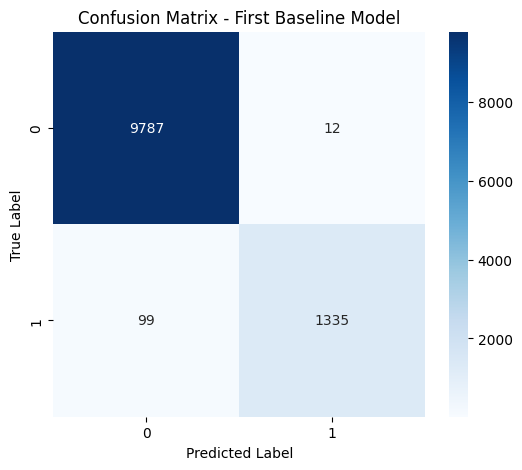

✅ Model saved locally
✅ Model also saved to Google Drive:
   /content/drive/MyDrive/seizure_prediction_data/baseline_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - First Baseline Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Save model locally
torch.save(model.state_dict(), "/content/baseline_model.pth")
print("✅ Model saved locally")

# Save model to Google Drive (permanent)
import os
drive_dir = "/content/drive/MyDrive/seizure_prediction_data"
os.makedirs(drive_dir, exist_ok=True)
drive_model_path = os.path.join(drive_dir, "baseline_model.pth")
torch.save(model.state_dict(), drive_model_path)
print(f"✅ Model also saved to Google Drive:")
print(f"   {drive_model_path}")
from google.colab import files
# Download to your local computer
files.download("/content/baseline_model.pth")